In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import optuna
from stable_baselines3 import PPO
from datetime import datetime
import os
from rl_system_setting import load_real_data
from sklearn.mixture import GaussianMixture

# --- CONFIGURATION ---
CONFIG = {
    "WINDOW_SIZE": 60,
    "TX_COST_BPS": 0.0010,
    "RISK_AVERSION": 4.0,
    "SMA_WINDOW": 50,
    "RSI_WINDOW": 14
}
SEED = 42
# === SET ALL RANDOM SEEDS FOR REPRODUCIBILITY ===
import random
random.seed(SEED)
print(f'✓ All random seeds set to {SEED}')


# === ENHANCED SEED SETTING (with PyTorch) ===
import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'✓ PyTorch seed also set to {SEED}')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


✓ All random seeds set to 42
✓ PyTorch seed also set to 42


In [2]:
class FinancialFeatureEngineer:
    def preprocess_data(self, df):
        data = df.copy()
        asset_cols = [c for c in data.columns if c != 'SPY']
        
        # 1. Log Returns
        log_ret = np.log(data[asset_cols] / data[asset_cols].shift(1)).fillna(0)
        
        # 2. Volatility (Robust Scaling)
        # Use a longer window for mean/std to capture regime context
        roll_std = log_ret.rolling(20).std()
        long_term_std = roll_std.rolling(252).median() # Median is more robust to outliers than mean
        norm_vol = (roll_std / (long_term_std + 1e-8)) - 1.0
        
        # 3. RSI (Vectorized)
        delta = data[asset_cols].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        norm_rsi = (100 - (100 / (1 + rs))) / 100.0 # Scale 0 to 1 directly
        
        # 4. Trend (Z-Score of Price vs SMA)
        # Z-score is statistically better for RL than raw % distance
        sma_50 = data[asset_cols].rolling(50).mean()
        std_50 = data[asset_cols].rolling(50).std()
        z_score_sma = (data[asset_cols] - sma_50) / (std_50 + 1e-8)

        # 5. Relative Strength (Alpha)
        asset_cum = data[asset_cols].pct_change(60)
        bench_cum = data['SPY'].pct_change(60)
        rel_str = asset_cum.sub(bench_cum, axis=0)

        # Cleanup - Forward fill is financial standard
        features_list = [norm_vol, norm_rsi, z_score_sma, rel_str, log_ret]
        for i in range(len(features_list)):
            features_list[i] = features_list[i].ffill().bfill().fillna(0) # Handle NaN edges
            
        # Stack
        features = np.stack([f.values for f in features_list], axis=-1)
        
        # Clip huge outliers for RL stability
        features = np.clip(features, -5, 5)
        
        return features, data[asset_cols].values, data['SPY'].values

In [3]:
class BoardOfDirectorsV3:
    def __init__(self, bull_path, bear_path, sniper_path, tickers):
        self.bull = PPO.load(bull_path)
        self.bear = PPO.load(bear_path)
        self.sniper = PPO.load(sniper_path)
        # Identify defensive assets indices to nuke them during rallies
        self.defensive_indices = [i for i, t in enumerate(tickers) if t in ['GLD', 'TLT', 'XLP', 'XLE']]
        self.hedge_indices = self.defensive_indices # Alias for compatibility
        
    def _softmax(self, x):
        e = np.exp(x - np.max(x)); return e / e.sum()

    def predict(self, obs, market_vol, avg_trend_strength, panic_vol=0.02, strong_trend=0.02):
        
        p1, _ = self.bull.predict(obs, deterministic=True)
        p2, _ = self.bear.predict(obs, deterministic=True)
        p3, _ = self.sniper.predict(obs, deterministic=True)
        wb = self._softmax(p1); wbr = self._softmax(p2); ws = self._softmax(p3)
        
        # --- LOGIC ---
        
        # 1. RALLY (Aggressive Growth)
        if avg_trend_strength > strong_trend:
            # Use 100% Bull Agent
            raw_weights = wb
            
            # FORCE AGGRESSION:
            # A. Set Cash to 0
            raw_weights[-1] = -999.0 # Logits, effectively 0 after softmax
            
            # B. Kill Defensives (GLD, TLT)
            # We want pure Tech/Growth exposure
            for idx in self.defensive_indices:
                raw_weights[idx] = -999.0
            
            # Re-Softmax to normalize
            final_weights = self._softmax(raw_weights)
            return final_weights, "RALLY (Max Aggression)"
            
        # 2. CRASH
        elif market_vol > panic_vol:
            # Same Logic: Cash is King
            cash_only = np.zeros_like(wb); cash_only[-1] = 1.0
            return cash_only, "CRASH"
            
        # 3. NORMAL (Choppy/Sideways)
        else:
            # Here we keep the hedges
            return (0.6 * wb) + (0.4 * ws), "NORMAL"

In [4]:

class PortfolioRebalanceEnv(gym.Env):
    def __init__(self, price_data, features_data, benchmark_data, 
                 initial_balance=100_000, lookback_window=60):
        super().__init__()
        self.prices = price_data
        self.features = features_data
        self.benchmark = benchmark_data
        self.n_assets = self.prices.shape[1]
        self.n_features = self.features.shape[2]
        self.lookback_window = lookback_window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.n_assets + 1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-5, high=5, shape=(lookback_window, self.n_assets, self.n_features), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.lookback_window
        self.cash = 100_000.0
        self.shares = np.zeros(self.n_assets)
        self.portfolio_value = 100_000.0
        self.history_nav = [100_000.0]
        return self._get_obs(), {}

    def step(self, action):
        exp_action = np.exp(action)
        weights = exp_action / np.sum(exp_action)
        # Safety check: Normalize weights to prevent floating point drift
        weights = weights / np.sum(weights)
    
        current_prices = self.prices[self.current_step]
        target_val = self.portfolio_value * weights[:-1]
        current_holdings = self.shares * current_prices
        cost = np.sum(np.abs(target_val - current_holdings)) * CONFIG["TX_COST_BPS"]
        
        self.cash = (self.portfolio_value * weights[-1]) - cost
        self.shares = target_val / current_prices
        
        daily_ret = []
        steps = min(20, len(self.prices) - self.current_step - 1)
        for _ in range(steps):
            self.current_step += 1
            val = self.cash + np.sum(self.shares * self.prices[self.current_step])
            daily_ret.append(np.log(val / self.history_nav[-1]))
            self.history_nav.append(val)
            
        self.portfolio_value = self.history_nav[-1]
        
        # Dynamic Reward
        bench_slice = self.benchmark[self.current_step-20:self.current_step]
        mkt_vol = np.std(bench_slice) if len(bench_slice) > 1 else 0.01
        lam = CONFIG["RISK_AVERSION"] + ((mkt_vol - 0.015)*100 if mkt_vol > 0.015 else 0)
        
        r = np.array(daily_ret)
        downside = np.std(r[r<0]) if len(r[r<0]) > 0 else 0.0
        reward = np.sum(r) - (lam * downside)
        
        return self._get_obs(), reward, self.current_step >= len(self.prices) - 2, False, {}

    def _get_obs(self):
        return self.features[self.current_step-self.lookback_window : self.current_step].astype(np.float32)


In [5]:
# --- EXECUTION BLOCK ---
df_v3_1 = load_real_data()
engineer = FinancialFeatureEngineer()
features, prices, benchmark = engineer.preprocess_data(df_v3_1)

# Split
split = int(len(df_v3_1) * 0.8)
feat_train, feat_test = features[:split], features[split:]
price_train, price_test = prices[:split], prices[split:]
bench_train, bench_test = benchmark[:split], benchmark[split:]

📥 Downloading 12 assets from 2015-01-01 to 2025-11-30...
✅ Data Ready: 2744 rows x 12 columns
   Date Range: 2015-01-02 -> 2025-11-28


## The Problem: "Jack of All Trades, Master of None"

Currently, you feed the year 2008 (a crash) to the Bull Agent. The Bull Agent tries to buy stocks, loses money, and the PPO algorithm punishes it. The neural network learns "Buying is bad." Then, you feed the year 2021 (a rally) to the same agent. It buys, makes money, and learns "Buying is good."

The result? The Bull Agent becomes a mediocre average agent, not an aggressive specialist. The same applies to the Bear and Sniper.

The Solution: Regime-Filtered Training

To create true specialists, you must filter the training data so that each agent only sees the market conditions it is supposed to master.

1. The Concept

Bull Agent: Train only on uptrends (e.g., SPY > 50-day SMA).

Bear Agent: Train only on downtrends or high volatility (e.g., SPY < 50-day SMA or VIX > 20).

Sniper Agent: Train on everything (or specifically choppy/sideways markets) to act as the baseline.

2. The Implementation (Simple & Vectorized)

We don't need complex code. We just need to mask the step() function in the environment or pre-filter the data. The cleanest way for your current setup is to Split the Environments.

In [6]:
class RegimeAwareEnv(PortfolioRebalanceEnv):
    def __init__(self, price_data, features_data, benchmark_data, 
                 regime_mask=None, **kwargs):
        # Initialize the parent class
        super().__init__(price_data, features_data, benchmark_data, **kwargs)
        
        # If no mask is provided, treat all data as valid (Sniper/Generalist)
        if regime_mask is None:
            self.mask = np.ones(len(price_data), dtype=bool)
        else:
            self.mask = regime_mask
            
        # Pre-calculate valid starting points
        # Must be in regime AND have lookback history AND room for at least one step (20 days)
        valid_indices = np.where(self.mask)[0]
        self.valid_starts = valid_indices[
            (valid_indices >= self.lookback_window) & 
            (valid_indices < (len(price_data) - 22))
        ]
        
        # Also check that the forward window (20 days) stays in regime
        # Filter out starts where we'd exit the regime during the step
        truly_valid = []
        for start in self.valid_starts:
            end_step = min(start + 20, len(price_data) - 1)
            # Check if all steps in the forward window are in regime
            if np.all(self.mask[start:end_step+1]):
                truly_valid.append(start)
        self.valid_starts = np.array(truly_valid)
        
        if len(self.valid_starts) == 0:
            raise ValueError("No valid starting points found for this regime!")

    def reset(self, seed=None, options=None):
        # Standard Gym/Gymnasium seed handling
        super().reset(seed=seed) 
        
        # CRITICAL: Only start in a valid regime position
        if len(self.valid_starts) > 0:
            self.current_step = np.random.choice(self.valid_starts)
        else:
            # Fallback (shouldn't happen due to validation above)
            self.current_step = self.lookback_window
            
        # Re-initialize portfolio state (parent reset() already did this, but be explicit)
        self.cash = 100_000.0
        self.shares = np.zeros(self.n_assets)
        self.portfolio_value = 100_000.0
        self.history_nav = [100_000.0]
        
        return self._get_obs(), {}

    def step(self, action):
        # CRITICAL: Check BEFORE executing if we can complete the step
        # The parent step() will fast-forward 20 days, so check the forward window
        steps_to_take = min(20, len(self.prices) - self.current_step - 1)
        end_step = self.current_step + steps_to_take
        
        # Check if the entire forward window is in our regime
        if not np.all(self.mask[self.current_step:end_step+1]):
            # We're about to exit the regime, terminate early
            # Return current observation with zero reward and done=True
            obs = self._get_obs()
            return obs, 0.0, True, False, {"regime_exit": True}
        
        # Execute the action using parent class logic
        obs, reward, done, truncated, info = super().step(action)
        
        # Double-check: After parent step(), current_step has moved forward
        # Verify we're still in regime (should be true if pre-check passed)
        if not self.mask[self.current_step]:
            done = True
            info["regime_exit"] = True
            
        return obs, reward, done, truncated, info

In [7]:
# --- 1. Define Regimes (Ground Truth from Benchmark) ---
spy_train = bench_train

# Use lagged SMA to prevent lookahead bias
spy_series = pd.Series(spy_train)
spy_sma = spy_series.rolling(50).mean().shift(1).fillna(spy_series.iloc[0])  # Shift to use past SMA
spy_vol = spy_series.pct_change().rolling(20).std().fillna(0.01)

# Boolean Masks (Same length as data)
# Bull Mask: Price > Lagged SMA AND Low Volatility
mask_bull = (spy_train > spy_sma.values) & (spy_vol.values < 0.02)
# Convert to pandas Series to handle any NaNs, then back to numpy array
mask_bull = pd.Series(mask_bull).fillna(False).values.astype(bool)

# Bear Mask: Not Bull (Price <= SMA OR High Volatility)
mask_bear = ~mask_bull

# Validation
assert len(mask_bull) == len(price_train) == len(feat_train) == len(bench_train), \
    f"Mask length mismatch: bull={len(mask_bull)}, prices={len(price_train)}"

print(f"Regime Distribution:")
print(f"  Bull periods: {mask_bull.sum()} ({mask_bull.sum()/len(mask_bull)*100:.1f}%)")
print(f"  Bear periods: {mask_bear.sum()} ({mask_bear.sum()/len(mask_bear)*100:.1f}%)")

# --- 2. Train with Regime-Aware Envs ---
print("\nTraining Regime-Aware Specialists...")

# Bull Agent (Only plays 'Game of Bull')
env_bull = RegimeAwareEnv(price_train, feat_train, bench_train, regime_mask=mask_bull)
model_bull = PPO("MlpPolicy", env_bull, verbose=0, learning_rate=0.0003)
model_bull.learn(total_timesteps=30_000)
model_bull.save("agent_bull")
print("✓ Bull agent trained")

# Bear Agent (Only plays 'Game of Bear')
env_bear = RegimeAwareEnv(price_train, feat_train, bench_train, regime_mask=mask_bear)
model_bear = PPO("MlpPolicy", env_bear, verbose=0, ent_coef=0.05, learning_rate=0.0003)  # Higher exploration for bear
model_bear.learn(total_timesteps=30_000)
model_bear.save("agent_bear")
print("✓ Bear agent trained")

# Sniper (Generalist - No Mask)
env_sniper = RegimeAwareEnv(price_train, feat_train, bench_train, regime_mask=None)
model_sniper = PPO("MlpPolicy", env_sniper, verbose=0)
model_sniper.learn(total_timesteps=30_000)
model_sniper.save("agent_sniper")
print("✓ Sniper agent trained")

print("\n✓ Specialists trained with sequence integrity.")

# Create train_env for backward compatibility with optimization code
train_env = PortfolioRebalanceEnv(price_train, feat_train, bench_train)

Regime Distribution:
  Bull periods: 1499 (68.3%)
  Bear periods: 696 (31.7%)

Training Regime-Aware Specialists...
✓ Bull agent trained
✓ Bear agent trained
✓ Sniper agent trained

✓ Specialists trained with sequence integrity.


In [8]:
# --- 1. Pre-compute Logits & Signals ---
print("Pre-computing signals for optimization...")
# Get tickers directly from the dataframe to ensure indices align perfectly
# (The loader puts 'SPY' at the end, so we exclude it)
ACTUAL_TICKERS = [col for col in df_v3_1.columns if col != 'SPY']
print(f"✓ optimization alignment: {len(ACTUAL_TICKERS)} assets")

# Initialize Board with V3.1 Logic
board = BoardOfDirectorsV3("agent_bull", "agent_bear", "agent_sniper", ACTUAL_TICKERS)

indices = range(60, len(price_train)-22, 20)
w_bull, w_bear, w_sniper = [], [], []
signals = []

for i in indices:
    # 1. Get Agent Predictions (Logits)
    obs = train_env.features[i-60:i]
    p1, _ = board.bull.predict(obs, deterministic=True)
    p2, _ = board.bear.predict(obs, deterministic=True)
    p3, _ = board.sniper.predict(obs, deterministic=True)
    w_bull.append(p1); w_bear.append(p2); w_sniper.append(p3)
    
    # 2. Get V3.1 Signals
    # Market Volatility (5-day)
    b_slice = train_env.benchmark[i-5:i]
    vol = pd.Series(b_slice).pct_change().std() if len(b_slice)>1 else 0.01
    if np.isnan(vol): vol = 0.01
    
    # Trend Strength (Relative Strength - Index 3 in V3.1 Features)
    latest_feats = obs[-1]
    avg_trend = np.mean(latest_feats[:, 3]) 
    
    signals.append((vol, avg_trend))

w_bull = np.array(w_bull); w_bear = np.array(w_bear); w_sniper = np.array(w_sniper)

# --- 2. The V3.1 Fast Engine ---
class TurboLogicEngineV3:
    def __init__(self, prices, wb, wbr, ws, sigs, idxs, n_assets, defensive_indices):
        self.prices = prices
        self.wb = wb; self.wbr = wbr; self.ws = ws
        self.sigs = sigs; self.idxs = idxs
        self.n_assets = n_assets
        self.def_idxs = defensive_indices
        self.tx_cost = CONFIG["TX_COST_BPS"] # BUG FIX: Use Config
        
    def _softmax(self, x):
        e = np.exp(x - np.max(x)); return e / e.sum()

    def run(self, panic_vol, strong_trend):
        cash = 100_000.0
        shares = np.zeros(self.n_assets)
        hist = []
        
        for ptr, i in enumerate(self.idxs):
            vol, trend = self.sigs[ptr]
            
            # V3.1 LOGIC IMPLEMENTATION
            if trend > strong_trend:
                # RALLY: Force 100% Bull, Kill Cash, Kill Hedges
                raw_w = self.wb[ptr].copy()
                raw_w[-1] = -999.0 # Cash
                for d_i in self.def_idxs: raw_w[d_i] = -999.0 # Defensives
                tw = self._softmax(raw_w)
                reg = "RALLY"
            elif vol > panic_vol:
                # CRASH: 100% Cash
                tw = np.zeros(self.n_assets + 1); tw[-1] = 1.0
                reg = "CRASH"
            else:
                # NORMAL: 60/40 Mix
                wb = self._softmax(self.wb[ptr])
                ws = self._softmax(self.ws[ptr])
                tw = (0.6 * wb) + (0.4 * ws)
                reg = "NORMAL"

            # Execution Wrapper
            p = self.prices[i]
            val = cash + np.sum(shares * p)
            if val > 0: cw = np.append((shares*p)/val, cash/val)
            else: cw = np.zeros_like(tw); cw[-1] = 1.0
            
            # Fast exit in Crash/Rally
            act_thresh = 0.01 if reg != "NORMAL" else 0.05
            
            if np.sum(np.abs(tw - cw)) > act_thresh:
                t_val = val * tw
                cost = np.sum(np.abs(t_val[:-1] - (shares*p))) * self.tx_cost
                cash = t_val[-1] - cost
                shares = t_val[:-1] / p
            
            # Fast Forward
            end = min(i+20, len(self.prices))
            m_p = self.prices[i+1:end+1]
            m_nav = cash + np.dot(m_p, shares)
            hist.extend(m_nav)
            
        return np.array(hist)

# --- 3. Optuna Optimization ---
def objective(trial):
    # Tune the definition of "Panic" and "Strong Trend"
    p_vol = trial.suggest_float("panic_vol", 0.015, 0.035)
    p_trend = trial.suggest_float("strong_trend", 0.005, 0.05) 
    
    engine = TurboLogicEngineV3(
        price_train, w_bull, w_bear, w_sniper, signals, indices, 
        train_env.n_assets, board.hedge_indices
    )
    nav = engine.run(p_vol, p_trend)
    
    if len(nav) == 0: return -100
    
    # 1. Calculate CAGR
    total_ret = (nav[-1] / nav[0]) - 1
    
    # 2. Calculate Max Drawdown (Vectorized)
    running_max = np.maximum.accumulate(nav)
    drawdown = (nav - running_max) / running_max
    max_dd = np.min(drawdown)
    
    # 3. Calmar Ratio (Return / Abs(MaxDD))
    # Add a small epsilon to avoid division by zero
    calmar = total_ret / (abs(max_dd) + 0.05) 
    
    # Penalize if drawdown is catastrophic (>30%)
    if max_dd < -0.30:
        return -100
        
    return calmar # Maximizing Risk-Adjusted Return

# Use fixed seed for optimizer to ensure consistency in testing
import torch
torch.manual_seed(SEED)
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=100)
BP = study.best_params
print(f"Best Parameters: {BP}")

[I 2025-11-30 09:38:23,389] A new study created in memory with name: no-name-aa2ba4d0-1f9d-480d-94cc-d721fc878be3
[I 2025-11-30 09:38:23,392] Trial 0 finished with value: 15.269423569484651 and parameters: {'panic_vol': 0.022490802376947252, 'strong_trend': 0.04778214378844623}. Best is trial 0 with value: 15.269423569484651.
[I 2025-11-30 09:38:23,395] Trial 1 finished with value: -100.0 and parameters: {'panic_vol': 0.029639878836228106, 'strong_trend': 0.03193963178886665}. Best is trial 0 with value: 15.269423569484651.
[I 2025-11-30 09:38:23,398] Trial 2 finished with value: 32.65599784094373 and parameters: {'panic_vol': 0.01812037280884873, 'strong_trend': 0.01201975341512912}. Best is trial 2 with value: 32.65599784094373.
[I 2025-11-30 09:38:23,400] Trial 3 finished with value: -100.0 and parameters: {'panic_vol': 0.01616167224336399, 'strong_trend': 0.04397792655987209}. Best is trial 2 with value: 32.65599784094373.
[I 2025-11-30 09:38:23,403] Trial 4 finished with value: -1

Pre-computing signals for optimization...
✓ optimization alignment: 11 assets


[I 2025-11-30 09:38:23,502] Trial 32 finished with value: 33.16196733258437 and parameters: {'panic_vol': 0.020447701651499235, 'strong_trend': 0.012205365474751978}. Best is trial 31 with value: 37.27956456494309.
[I 2025-11-30 09:38:23,513] Trial 33 finished with value: -100.0 and parameters: {'panic_vol': 0.022240928436180914, 'strong_trend': 0.0069122352379251}. Best is trial 31 with value: 37.27956456494309.
[I 2025-11-30 09:38:23,551] Trial 34 finished with value: -100.0 and parameters: {'panic_vol': 0.015219783784875424, 'strong_trend': 0.010893140829365969}. Best is trial 31 with value: 37.27956456494309.
[I 2025-11-30 09:38:23,556] Trial 35 finished with value: 20.056469695435233 and parameters: {'panic_vol': 0.017896501746910546, 'strong_trend': 0.04383172948339638}. Best is trial 31 with value: 37.27956456494309.
[I 2025-11-30 09:38:23,565] Trial 36 finished with value: 22.46013322896928 and parameters: {'panic_vol': 0.019294676312294503, 'strong_trend': 0.019189156342017913

Best Parameters: {'panic_vol': 0.02105067146965672, 'strong_trend': 0.006381332353051378}


In [9]:
# --- 1. Pre-compute Logits & Signals ---
print("Pre-computing signals for optimization...")

# Re-initialize Board with V3.1 Logic
# Use dynamic ticker list from dataframe to ensure alignment
ACTUAL_TICKERS = [col for col in df_v3_1.columns if col != 'SPY']
board = BoardOfDirectorsV3("agent_bull", "agent_bear", "agent_sniper", ACTUAL_TICKERS)

indices = range(60, len(price_train)-22, 20)
w_bull, w_bear, w_sniper = [], [], []
signals = []

for i in indices:
    # 1. Get Agent Predictions (Logits)
    obs = train_env.features[i-60:i]
    p1, _ = board.bull.predict(obs, deterministic=True)
    p2, _ = board.bear.predict(obs, deterministic=True)
    p3, _ = board.sniper.predict(obs, deterministic=True)
    w_bull.append(p1); w_bear.append(p2); w_sniper.append(p3)
    
    # 2. Get V3.1 Signals
    # Market Volatility (5-day)
    b_slice = train_env.benchmark[i-5:i]
    vol = pd.Series(b_slice).pct_change().std() if len(b_slice)>1 else 0.01
    if np.isnan(vol): vol = 0.01
    
    # Trend Strength (Relative Strength - Index 3 in V3.1 Features)
    # Shape is (Window, Assets, Features) -> Get last step [-1], all assets [:], feature index 3
    latest_feats = obs[-1]
    avg_trend = np.mean(latest_feats[:, 3]) 
    
    signals.append((vol, avg_trend))

w_bull = np.array(w_bull); w_bear = np.array(w_bear); w_sniper = np.array(w_sniper)

# --- 2. The V3.1 Fast Engine ---
class TurboLogicEngineV3:
    def __init__(self, prices, wb, wbr, ws, sigs, idxs, n_assets, defensive_indices):
        self.prices = prices
        self.wb = wb; self.wbr = wbr; self.ws = ws
        self.sigs = sigs; self.idxs = idxs
        self.n_assets = n_assets
        self.def_idxs = defensive_indices
        self.tx_cost = CONFIG["TX_COST_BPS"]  # Use Config for consistency
        
    def _softmax(self, x):
        e = np.exp(x - np.max(x)); return e / e.sum()

    def run(self, panic_vol, strong_trend):
        cash = 100_000.0
        shares = np.zeros(self.n_assets)
        hist = []
        
        for ptr, i in enumerate(self.idxs):
            vol, trend = self.sigs[ptr]
            
            # V3.1 LOGIC IMPLEMENTATION
            if trend > strong_trend:
                # RALLY: Force 100% Bull, Kill Cash, Kill Hedges
                raw_w = self.wb[ptr].copy()
                raw_w[-1] = -999.0 # Cash
                for d_i in self.def_idxs: raw_w[d_i] = -999.0 # Defensives
                tw = self._softmax(raw_w)
                reg = "RALLY"
            elif vol > panic_vol:
                # CRASH: 100% Cash
                tw = np.zeros(self.n_assets + 1); tw[-1] = 1.0
                reg = "CRASH"
            else:
                # NORMAL: 60/40 Mix
                wb = self._softmax(self.wb[ptr])
                ws = self._softmax(self.ws[ptr])
                tw = (0.6 * wb) + (0.4 * ws)
                reg = "NORMAL"

            # Execution Wrapper
            p = self.prices[i]
            val = cash + np.sum(shares * p)
            if val > 0: cw = np.append((shares*p)/val, cash/val)
            else: cw = np.zeros_like(tw); cw[-1] = 1.0
            
            # Fast exit in Crash/Rally
            act_thresh = 0.01 if reg != "NORMAL" else 0.05
            
            if np.sum(np.abs(tw - cw)) > act_thresh:
                t_val = val * tw
                cost = np.sum(np.abs(t_val[:-1] - (shares*p))) * self.tx_cost
                cash = t_val[-1] - cost
                shares = t_val[:-1] / p
            
            # Fast Forward
            end = min(i+20, len(self.prices))
            m_p = self.prices[i+1:end+1]
            m_nav = cash + np.dot(m_p, shares)
            hist.extend(m_nav)
            
        return np.array(hist)

# --- 3. Optuna Optimization ---
def objective(trial):
    # Tune the definition of "Panic" and "Strong Trend"
    p_vol = trial.suggest_float("panic_vol", 0.015, 0.035)
    p_trend = trial.suggest_float("strong_trend", 0.005, 0.05) # 0.5% to 5% Outperformance vs SPY
    
    engine = TurboLogicEngineV3(
        price_train, w_bull, w_bear, w_sniper, signals, indices, 
        train_env.n_assets, board.hedge_indices
    )
    nav = engine.run(p_vol, p_trend)
    
    if len(nav) == 0: return -100
    
    # 1. Calculate CAGR
    total_ret = (nav[-1] / nav[0]) - 1
    
    # 2. Calculate Max Drawdown (Vectorized)
    running_max = np.maximum.accumulate(nav)
    drawdown = (nav - running_max) / running_max
    max_dd = np.min(drawdown)
    
    # 3. Calmar Ratio (Return / Abs(MaxDD))
    # Add a small epsilon to avoid division by zero
    calmar = total_ret / (abs(max_dd) + 0.05) 
    
    # Penalize if drawdown is catastrophic (>30%)
    if max_dd < -0.30:
        return -100
        
    return calmar # Maximizing Risk-Adjusted Return

import torch
torch.manual_seed(SEED)
sampler = optuna.samplers.TPESampler(seed=SEED)
# Reset seeds before optimization
np.random.seed(SEED)
random.seed(SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=100)
BP = study.best_params
print(f"Best Parameters: {BP}")

[I 2025-11-30 09:38:23,975] A new study created in memory with name: no-name-3159e8a6-dde9-42b8-b936-4220e6e19f0b
[I 2025-11-30 09:38:23,978] Trial 0 finished with value: 15.269423569484651 and parameters: {'panic_vol': 0.022490802376947252, 'strong_trend': 0.04778214378844623}. Best is trial 0 with value: 15.269423569484651.
[I 2025-11-30 09:38:23,980] Trial 1 finished with value: -100.0 and parameters: {'panic_vol': 0.029639878836228106, 'strong_trend': 0.03193963178886665}. Best is trial 0 with value: 15.269423569484651.
[I 2025-11-30 09:38:23,983] Trial 2 finished with value: 32.65599784094373 and parameters: {'panic_vol': 0.01812037280884873, 'strong_trend': 0.01201975341512912}. Best is trial 2 with value: 32.65599784094373.
[I 2025-11-30 09:38:23,990] Trial 3 finished with value: -100.0 and parameters: {'panic_vol': 0.01616167224336399, 'strong_trend': 0.04397792655987209}. Best is trial 2 with value: 32.65599784094373.
[I 2025-11-30 09:38:23,993] Trial 4 finished with value: -1

Pre-computing signals for optimization...


[I 2025-11-30 09:38:24,045] Trial 20 finished with value: 16.72058445589535 and parameters: {'panic_vol': 0.016947203129017905, 'strong_trend': 0.0360291470504289}. Best is trial 12 with value: 36.221032946609796.
[I 2025-11-30 09:38:24,049] Trial 21 finished with value: 34.63056259630803 and parameters: {'panic_vol': 0.02143439925502336, 'strong_trend': 0.00839996371418688}. Best is trial 12 with value: 36.221032946609796.
[I 2025-11-30 09:38:24,052] Trial 22 finished with value: -100.0 and parameters: {'panic_vol': 0.022494126249917246, 'strong_trend': 0.00851312177698199}. Best is trial 12 with value: 36.221032946609796.
[I 2025-11-30 09:38:24,056] Trial 23 finished with value: 36.18244160903218 and parameters: {'panic_vol': 0.020158660671677306, 'strong_trend': 0.008841664668950254}. Best is trial 12 with value: 36.221032946609796.
[I 2025-11-30 09:38:24,060] Trial 24 finished with value: 23.45250389782815 and parameters: {'panic_vol': 0.01932021988863136, 'strong_trend': 0.0184140

Best Parameters: {'panic_vol': 0.02105067146965672, 'strong_trend': 0.006381332353051378}



REGIME DECISION BOUNDARY VISUALIZATION


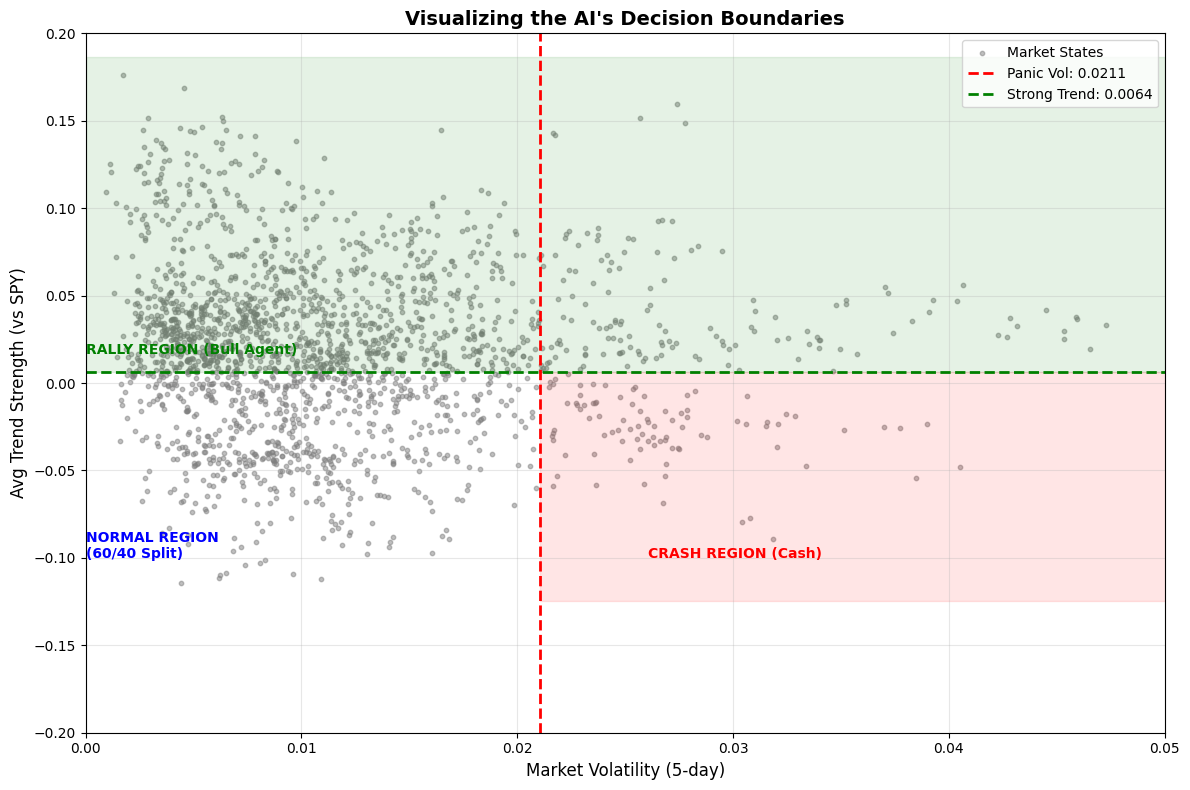

In [10]:
# --- Regime Map Visualization ---
# This visualization explains why the AI made money by plotting the decision boundaries found by Optuna
import matplotlib.patches as mpatches

def plot_regime_decision_boundary(study, price_data, benchmark_data):
    """
    Visualize the decision boundaries learned by Optuna optimization.
    Shows how the AI classifies market regimes based on volatility and trend strength.
    """
    # Extract best params
    best_vol = study.best_params['panic_vol']
    best_trend = study.best_params['strong_trend']
    
    # Calculate historical metrics for the whole period to visualize distribution
    b_series = pd.Series(benchmark_data)
    hist_vol = b_series.pct_change().rolling(5).std()
    
    # Calculate average trend across assets
    # Reconstructing simple relative strength for viz
    price_df = pd.DataFrame(price_data)
    asset_mean_trend = price_df.pct_change(60).mean(axis=1) - b_series.pct_change(60)
    
    plt.figure(figsize=(12, 8))
    
    # Scatter plot of market states
    plt.scatter(hist_vol, asset_mean_trend, alpha=0.5, c='gray', s=10, label='Market States')
    
    # Draw Thresholds
    plt.axvline(best_vol, color='red', linestyle='--', linewidth=2, label=f'Panic Vol: {best_vol:.4f}')
    plt.axhline(best_trend, color='green', linestyle='--', linewidth=2, label=f'Strong Trend: {best_trend:.4f}')
    
    # Shade Regions based on the decision logic:
    # 1. RALLY (Trend > Strong) - Uses Bull Agent
    plt.axhspan(best_trend, asset_mean_trend.max() + 0.01, color='green', alpha=0.1)
    plt.text(0.0, best_trend + 0.01, "RALLY REGION (Bull Agent)", color='green', fontweight='bold')
    
    # 2. CRASH (Vol > Panic AND Trend < Strong) - Goes to Cash
    plt.fill_between([best_vol, hist_vol.max() + 0.01], asset_mean_trend.min() - 0.01, best_trend, color='red', alpha=0.1)
    plt.text(best_vol + 0.005, -0.1, "CRASH REGION (Cash)", color='red', fontweight='bold')
    
    # 3. NORMAL - 60/40 Split
    plt.text(0.0, -0.1, "NORMAL REGION\n(60/40 Split)", color='blue', fontweight='bold')

    plt.xlabel("Market Volatility (5-day)", fontsize=12)
    plt.ylabel("Avg Trend Strength (vs SPY)", fontsize=12)
    plt.title("Visualizing the AI's Decision Boundaries", fontsize=14, fontweight='bold')
    plt.legend(loc='upper right')
    plt.xlim(0, 0.05)  # Zoom in on relevant area
    plt.ylim(-0.2, 0.2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Call this after optimization to visualize the decision boundaries
print("\n" + "="*80)
print("REGIME DECISION BOUNDARY VISUALIZATION")
print("="*80)
plot_regime_decision_boundary(study, price_train, bench_train)


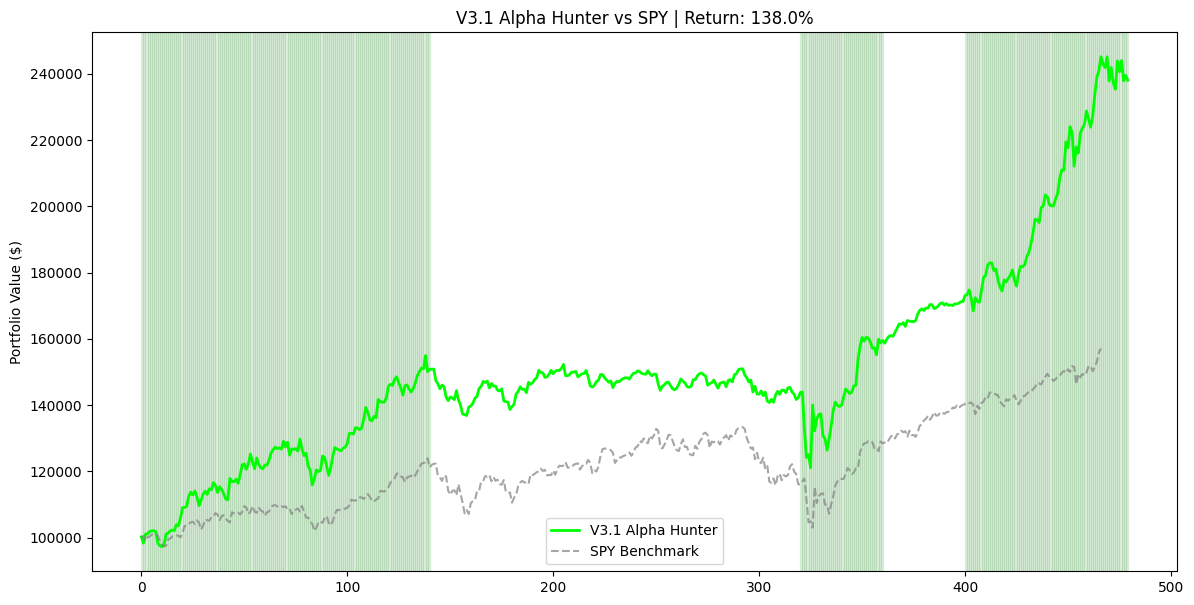

AI Return: 138.05%
SPY Return: 57.08%
Alpha: 80.97%


In [11]:
# 1. Setup V3.1 Backtester
class FinalV3Backtester:
    def __init__(self, board, env, p_vol, p_trend):
        self.board = board; self.env = env
        self.p_vol = p_vol; self.p_trend = p_trend
        self.tx_cost = CONFIG["TX_COST_BPS"]
        
    def run(self):
        cash = 100_000.0
        shares = np.zeros(self.env.n_assets)
        history = []
        curr = self.env.lookback_window
        end = len(self.env.prices) - 22
        
        while curr < end:
            # Live Signals
            b_slice = self.env.benchmark[curr-5:curr]
            vol = pd.Series(b_slice).pct_change().std() if len(b_slice)>1 else 0.01
            if np.isnan(vol): vol = 0.01
            
            obs = self.env.features[curr-60:curr]
            # Index 3 = Relative Strength (Alpha) - used for trend strength signal
            avg_trend = np.mean(obs[-1, :, 3])
            
            # Predict
            target_w, regime = self.board.predict(obs, vol, avg_trend, self.p_vol, self.p_trend)
            
            # Execute
            p = self.env.prices[curr]
            val = cash + np.sum(shares * p)
            if val > 0: cw = np.append((shares*p)/val, cash/val)
            else: cw = np.zeros_like(target_w); cw[-1] = 1.0
            
            act_thresh = 0.01 if regime != "NORMAL" else 0.05
            if np.sum(np.abs(target_w - cw)) > act_thresh:
                t_val = val * target_w
                cost = np.sum(np.abs(t_val[:-1] - (shares*p))) * self.tx_cost
                cash = t_val[-1] - cost
                shares = t_val[:-1] / p
                
            # Sim
            for t in range(20):
                idx = curr + t + 1
                nav = cash + np.sum(shares * self.env.prices[idx])
                history.append({'step': idx, 'nav': nav, 'regime': regime})
            curr += 20
            
        return pd.DataFrame(history)

# 2. Execute
test_env = PortfolioRebalanceEnv(price_test, feat_test, bench_test)
# ... Running Backtester ...
if 'BP' not in locals(): BP = {'panic_vol': 0.029, 'strong_trend': 0.01}
final_tester = FinalV3Backtester(board, test_env, BP['panic_vol'], BP['strong_trend'])
results = final_tester.run()

# 3. Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
# Plot AI NAV
plt.plot(results['nav'], color='lime', linewidth=2, label='V3.1 Alpha Hunter')

# Plot Benchmark (SPY)
spy_prices = test_env.benchmark[test_env.lookback_window : len(test_env.benchmark)-22]
spy_nav = (spy_prices / spy_prices[0]) * 100000
plt.plot(spy_nav, color='gray', linestyle='--', alpha=0.7, label='SPY Benchmark')

# Color Regimes
regime_map = {'RALLY (Max Aggression)': 'green', 'NORMAL': 'blue', 'CRASH': 'red'}
for start, end in zip(results.index[:-1], results.index[1:]):
    reg = results.loc[start, 'regime']
    col = regime_map.get(reg, 'white')
    if reg == 'RALLY (Max Aggression)': # Highlight the alpha zones
        plt.axvspan(start, end, color=col, alpha=0.1)

plt.title(f"V3.1 Alpha Hunter vs SPY | Return: {((results['nav'].iloc[-1]/100000)-1)*100:.1f}%")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.show()

# Stats
ai_ret = (results['nav'].iloc[-1] / 100000) - 1
spy_ret = (spy_nav[-1] / 100000) - 1
print(f"AI Return: {ai_ret:.2%}")
print(f"SPY Return: {spy_ret:.2%}")
print(f"Alpha: {(ai_ret - spy_ret):.2%}")